In [1]:
import torch
from model.model_mae import WaveformMAE
from model.data import WaveformDataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())

2.14.0+cu126
True


In [3]:
PATCH_SIZE = 50        # samples per patch: 50 * 0.01 ms = 0.5 ms of signal
ENCODER_DIM = 64       # hidden dimension of the encoder transformer
ENCODER_HEADS = 4      # attention heads in encoder
ENCODER_LAYERS = 3     # depth of encoder
DECODER_DIM = 32       # decoder is intentionally smaller — it's just a training tool
DECODER_HEADS = 4
DECODER_LAYERS = 1
DROPOUT = 0.1
MAX_PATCHES = 128      # max sequence length (128 * 50 = 6400 samples)
MASK_RATIO = 0.5   
GRADIENT_CLIP = 1

filepath = r"C:\Users\chris\Desktop\coding projects\AP-foundation-model-v2\waveforms\hh_dataset_1ms.h5"

dataset = WaveformDataset(filepath)
train_set, val_set = random_split(dataset, [0.8, 0.2])
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

model = WaveformMAE(
    patch_size=PATCH_SIZE,        # 50
    encoder_dim=ENCODER_DIM,      # 64
    encoder_heads=ENCODER_HEADS,  # 4
    encoder_layers=ENCODER_LAYERS,# 3
    decoder_dim=DECODER_DIM,      # 32
    decoder_heads=DECODER_HEADS,  # 4
    decoder_layers=DECODER_LAYERS,# 1
    dropout=DROPOUT,              # 0.1
    max_patches=MAX_PATCHES,      # 128
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using: ", device)

model = model.to(device)

Using:  cuda


In [4]:
# where loader is the DataLoader object and training is a boolean for toggling between training and test/validation
def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    num_batches = 0
    context = torch.enable_grad() if training else torch.inference_mode()

    with context:
        for parameters, voltage in loader:        # MAE ignores parameters
            voltage = voltage.to(device)

            if training:
                optimizer.zero_grad(set_to_none=True)

            pred_patches, mask = model(voltage, mask_ratio=MASK_RATIO)
            target_patches = model.patchify(voltage)
            per_patch_mse = ((pred_patches - target_patches) ** 2).mean(dim=-1)
            loss = (per_patch_mse * mask).sum() / mask.sum()

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
                optimizer.step()

            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
num_epochs = 500

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:>3}/{num_epochs} | MSE: {train_loss:.6f}")

torch.save({
"model": model.state_dict(),
"optimizer": optimizer.state_dict(),
"epoch": num_epochs,
"train_losses": train_losses,
"val_losses": val_losses,

"config": {
        "patch_size": PATCH_SIZE,
        "encoder_dim": ENCODER_DIM,
        "encoder_heads": ENCODER_HEADS,
        "encoder_layers": ENCODER_LAYERS,
        "decoder_dim": DECODER_DIM,
        "decoder_heads": DECODER_HEADS,
        "decoder_layers": DECODER_LAYERS,
        "dropout": DROPOUT,
        "max_patches": MAX_PATCHES,
        "mask_ratio": MASK_RATIO,
        "lr": 1e-4,
        "batch_size": 8,
    },

"voltage_mean": dataset.voltage_mean,
"voltage_std": dataset.voltage_std,
}, "mae_checkpoint.pt")

Epoch   1/500 | MSE: 0.876579
Epoch   2/500 | MSE: 0.492438


KeyboardInterrupt: 

In [6]:
checkpoint = torch.load("mae_checkpoint.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])
start_epoch = checkpoint["epoch"]

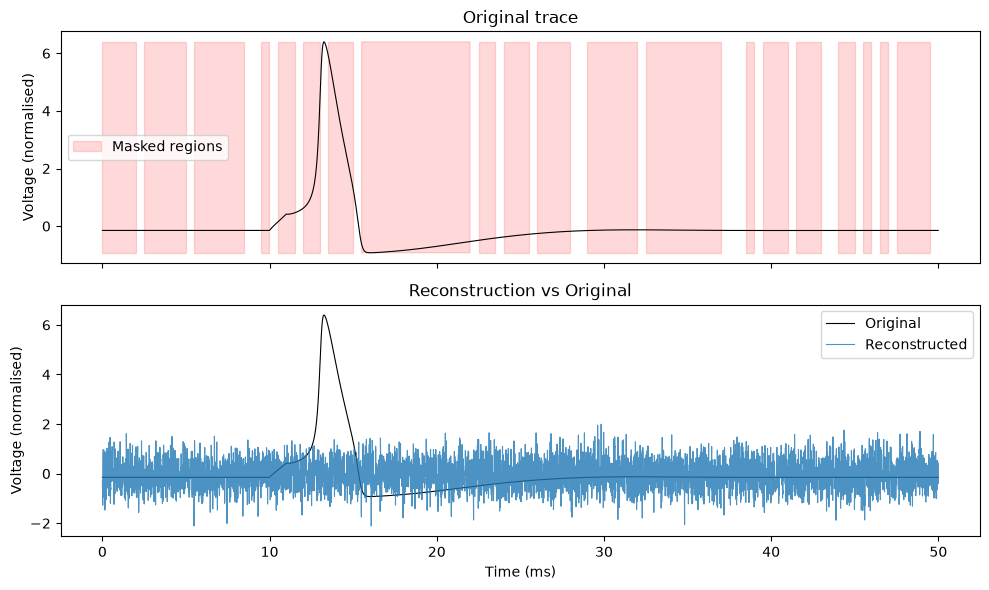

In [4]:
model.eval()
parameters, voltage = next(iter(val_loader))
voltage = voltage.to(device)

# Run forward pass — get predictions and which patches were masked
with torch.inference_mode():
    pred_patches, mask = model(voltage, mask_ratio=MASK_RATIO)

# Pick one trace from the batch
idx = 0
target = model.patchify(voltage)[idx].cpu()    # (num_patches, patch_size)
pred = pred_patches[idx].cpu()                  # (num_patches, patch_size)
m = mask[idx].cpu()                             # (num_patches,) 1=masked

# Rebuild full-length traces
original = target.reshape(-1).numpy()
reconstructed = pred.reshape(-1).numpy()

# Build a per-sample mask for shading masked regions
patch_mask = m.unsqueeze(-1).expand_as(target).reshape(-1).numpy()

t = dataset.time[:len(original)] * 1000  # convert to ms

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Top: original trace with masked regions shaded
axes[0].plot(t, original, color="black", linewidth=0.8)
axes[0].fill_between(t, original.min(), original.max(),
                      where=patch_mask.astype(bool), alpha=0.15, color="red",
                      label="Masked regions")
axes[0].set_ylabel("Voltage (normalised)")
axes[0].set_title("Original trace")
axes[0].legend()

# Bottom: overlay original and reconstruction
axes[1].plot(t, original, color="black", linewidth=0.8, label="Original")
axes[1].plot(t, reconstructed, color="tab:blue", linewidth=0.8,
             alpha=0.8, label="Reconstructed")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Voltage (normalised)")
axes[1].set_title("Reconstruction vs Original")
axes[1].legend()

plt.tight_layout()
plt.show()